In [2]:
RETRAIN = False

RUN_HOLDOUT_EVALUATION = True


# Autoencoder Training Notebook (BatchNorm Variant)

This notebook runs the BatchNorm autoencoder variant on the curated x64 benchmark split. By default it reuses saved artifacts from its local artifact folder and only retrains when `FORCE_RETRAIN = True`.


## Submission Context

- Dataset notebook: `data/dataset/x64/benchmark_50k_5pct/notebook.ipynb`
- Dataset config: `data/dataset/x64/benchmark_50k_5pct/data_config.toml`
- Experiment config: `experiments/anomaly_detection/autoencoder/x64/batchnorm/train_config.toml`
- Artifact root: `experiments/anomaly_detection/autoencoder/x64/batchnorm/artifacts/autoencoder_batchnorm`
- Default behavior: load the saved checkpoint, history, and score-ablation outputs if they already exist; only retrain when explicitly requested.


### Imports

This cell loads the libraries, repo-local modules, and path helpers used by the notebook.


In [3]:
from pathlib import Path
import json
import random
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score
import torch
from IPython.display import display
from torch.utils.data import DataLoader
cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
REPO_ROOT = None
for candidate in candidate_roots:
    if (candidate / 'src' / 'wafer_defect').exists() and (candidate / 'configs').exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError('Could not locate repo root containing src/wafer_defect and configs/')
SRC_ROOT = REPO_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))
from wafer_defect.config import load_toml
from wafer_defect.data.wm811k import WaferMapDataset
from wafer_defect.models.autoencoder import ConvAutoencoder, build_autoencoder_from_config
from wafer_defect.scoring import absolute_error_map, squared_error_map, spatial_mean, topk_spatial_mean
from wafer_defect.training.autoencoder import run_autoencoder_epoch


### Run Controls

This cell defines the experiment config path and the main rerun flags. Leave `RETRAIN = False          # False = use saved checkpoint; True = retrain from scratch` to reuse saved artifacts when they already exist.


In [4]:
CONFIG_PATH = REPO_ROOT / 'experiments/anomaly_detection/autoencoder/x64/batchnorm/train_config.toml'
EPOCHS_OVERRIDE = None
RERUN_SCORE_ABLATION = False
ANOMALY_SCORE_NAME = 'topk_abs_mean'
TOPK_RATIO = 0.01
config = load_toml(CONFIG_PATH)
if EPOCHS_OVERRIDE is not None:
    config['training']['epochs'] = int(EPOCHS_OVERRIDE)
config


{'run': {'output_dir': 'experiments/anomaly_detection/autoencoder/x64/batchnorm/artifacts/autoencoder_batchnorm',
  'seed': 42},
 'data': {'metadata_csv': 'data/processed/x64/wm811k/metadata_50k_5pct.csv',
  'image_size': 64,
  'batch_size': 64,
  'num_workers': 0},
 'training': {'epochs': 50,
  'learning_rate': 0.001,
  'weight_decay': 0.0001,
  'device': 'auto',
  'early_stopping_patience': 5,
  'early_stopping_min_delta': 5e-05,
  'checkpoint_every': 5,
  'resume_from': ''},
 'model': {'type': 'autoencoder', 'latent_dim': 128, 'use_batchnorm': True}}

### Reproducibility And Helpers

This cell sets the random seed, resolves the execution device, and defines a helper for saving figures.


In [5]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def resolve_device(device_name: str) -> torch.device:
    if device_name == 'auto':
        return torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    return torch.device(device_name)

def save_figure(fig: plt.Figure, path: Path) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, bbox_inches='tight', dpi=150)
    print(f'Saved figure to {path}')
    return path

def warn_skip(message: str) -> None:
    print(f'[WARNING] {message}')

set_seed(int(config['run']['seed']))
device = resolve_device(config['training']['device'])
device


device(type='cuda')

### Metadata Check

This cell loads the configured metadata CSV so we can verify the split before building loaders.


In [6]:
metadata_path = REPO_ROOT / config['data']['metadata_csv']
image_size = int(config['data'].get('image_size', 64))
metadata = pd.read_csv(metadata_path)
display(metadata.head())
display(metadata['split'].value_counts().rename_axis('split').to_frame('count'))
display(metadata['is_anomaly'].value_counts().rename_axis('is_anomaly').to_frame('count'))


,array_path,failure_type,failureTypeText,defect_type,label,is_anomaly,split
0,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...,none,none,none,none,0,train
1,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...,none,none,none,none,0,train
2,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...,none,none,none,none,0,train
3,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...,none,none,none,none,0,train
4,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...,none,none,none,none,0,train


,count
split,
train,40000
test,5250
val,5000


,count
is_anomaly,
0,50000
1,250


### Data Loaders

This cell builds the train, validation, and test loaders used throughout the notebook.


In [7]:
train_dataset = WaferMapDataset(metadata_path, split='train', image_size=image_size)
val_dataset = WaferMapDataset(metadata_path, split='val', image_size=image_size)
test_dataset = WaferMapDataset(metadata_path, split='test', image_size=image_size)
train_loader = DataLoader(train_dataset, batch_size=int(config['data']['batch_size']), shuffle=True, num_workers=int(config['data']['num_workers']))
val_loader = DataLoader(val_dataset, batch_size=int(config['data']['batch_size']), shuffle=False, num_workers=int(config['data']['num_workers']))
test_loader = DataLoader(test_dataset, batch_size=int(config['data']['batch_size']), shuffle=False, num_workers=int(config['data']['num_workers']))
print(f'train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}')


train=40000, val=5000, test=5250


### Model Setup

This cell constructs the model and optimizer that will be used either for training or for loading an existing checkpoint.


In [8]:
model = ConvAutoencoder(latent_dim=int(config['model']['latent_dim']), image_size=image_size, use_batchnorm=bool(config['model'].get('use_batchnorm', False)), dropout_prob=float(config['model'].get('dropout_prob', 0.0))).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=float(config['training']['learning_rate']), weight_decay=float(config['training']['weight_decay']))
model


ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=4096, out_features=128, bias=True)
    (11): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=4096, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(64, 8, 8))
    (3): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1,

### Training Or Artifact Reuse

This cell either trains the model or reuses the existing checkpoint and history files when they are already present.


In [9]:
history = []
epochs = int(config['training']['epochs'])
patience = int(config['training'].get('early_stopping_patience', 0))
min_delta = float(config['training'].get('early_stopping_min_delta', 0.0))
checkpoint_every = int(config['training'].get('checkpoint_every', 5))
resume_from = str(config['training'].get('resume_from', '')).strip()
best_val_loss = float('inf')
best_epoch = 0
best_state_dict = None
stale_epochs = 0
start_epoch = 0
training_ran = False
training_artifacts_ready = False
evaluation_ready = False
score_ablation_ready = False

output_dir = REPO_ROOT / config['run']['output_dir']
checkpoints_dir = output_dir / 'checkpoints'
results_dir = output_dir / 'results'

output_dir.mkdir(parents=True, exist_ok=True)
checkpoints_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

history_path = results_dir / 'history.json'
best_model_path = checkpoints_dir / 'best_model.pt'

artifacts_ready = best_model_path.exists() and history_path.exists()
if not RETRAIN and artifacts_ready:
    with history_path.open('r', encoding='utf-8') as handle:
        history = json.load(handle)
    best_checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(best_checkpoint['model_state_dict'])
    best_epoch = int(best_checkpoint.get('best_epoch', best_checkpoint.get('epoch', 0)))
    best_val_loss = float(best_checkpoint.get('best_val_loss', float('nan')))
    stale_epochs = int(best_checkpoint.get('stale_epochs', 0))
    best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    training_artifacts_ready = True
    print(f'Found existing artifacts in {output_dir}. Skipping training.')
elif RETRAIN:
    if 'train_loader' not in globals() or train_loader is None or val_loader is None:
        warn_skip('Training datasets are unavailable, so RETRAIN=True cannot run in this cell.')
    else:
        if resume_from:
            resume_path = Path(resume_from)
            if not resume_path.is_absolute():
                resume_path = REPO_ROOT / resume_path
            checkpoint = torch.load(resume_path, map_location=device)
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            start_epoch = int(checkpoint.get('epoch', 0))
            best_val_loss = float(checkpoint.get('best_val_loss', best_val_loss))
            best_epoch = int(checkpoint.get('best_epoch', best_epoch))
            stale_epochs = int(checkpoint.get('stale_epochs', stale_epochs))
            history = checkpoint.get('history', [])
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            print(f'Resumed from {resume_path} at epoch {start_epoch}')
        print({'epochs': epochs, 'anomaly_score': ANOMALY_SCORE_NAME, 'topk_ratio': TOPK_RATIO})
        for epoch in range(start_epoch, epochs):
            train_metrics = run_autoencoder_epoch(model, train_loader, device, optimizer)
            val_metrics = run_autoencoder_epoch(model, val_loader, device)
            record = {'epoch': epoch + 1, 'train_loss': train_metrics.loss, 'val_loss': val_metrics.loss}
            history.append(record)
            print(record)
            improved = best_val_loss - val_metrics.loss > min_delta
            if improved:
                best_val_loss = val_metrics.loss
                best_epoch = epoch + 1
                best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                stale_epochs = 0
                torch.save({'epoch': epoch + 1, 'model_state_dict': best_state_dict, 'optimizer_state_dict': optimizer.state_dict(), 'config': config, 'best_epoch': best_epoch, 'best_val_loss': best_val_loss, 'stale_epochs': stale_epochs, 'history': history}, output_dir / 'checkpoints' / 'best_model.pt')
            else:
                stale_epochs += 1
            latest_checkpoint = {'epoch': epoch + 1, 'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(), 'config': config, 'best_epoch': best_epoch, 'best_val_loss': best_val_loss, 'stale_epochs': stale_epochs, 'history': history}
            torch.save(latest_checkpoint, output_dir / 'checkpoints' / 'latest_checkpoint.pt')
            if checkpoint_every > 0 and (epoch + 1) % checkpoint_every == 0:
                torch.save(latest_checkpoint, output_dir / 'checkpoints' / f'checkpoint_epoch_{epoch + 1}.pt')
            if patience > 0 and stale_epochs >= patience:
                print(f'Early stopping at epoch {epoch + 1}. Best epoch: {best_epoch}, best val loss: {best_val_loss:.6f}')
                break
        if best_state_dict is None:
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        training_ran = True
        training_artifacts_ready = True
else:
    warn_skip('Saved training artifacts are missing and RETRAIN is False. Skipping this section.')


Found existing artifacts in C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\autoencoder\x64\batchnorm\artifacts\autoencoder_batchnorm. Skipping training.


### Training Curve

This cell displays the saved training history and exports the training-curve figure to the artifact folder.


Saved figure to C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\autoencoder\x64\batchnorm\artifacts\autoencoder_batchnorm\plots\training_curves.png


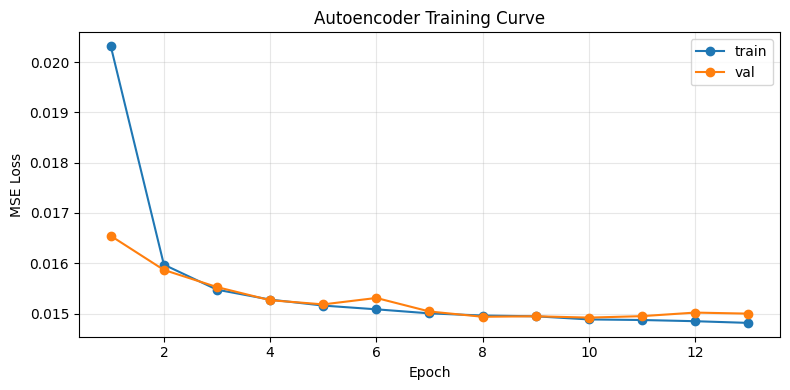

,epoch,train_loss,val_loss
8,9,0.014944,0.014945
9,10,0.014882,0.014919
10,11,0.014871,0.014947
11,12,0.014847,0.015018
12,13,0.014813,0.014998


In [10]:
if not history and history_path.exists():
    with history_path.open('r', encoding='utf-8') as handle:
        history = json.load(handle)
history_df = pd.DataFrame(history)
if history_df.empty:
    warn_skip('Training curves are unavailable because history.json is missing or empty.')
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='train')
    ax.plot(history_df['epoch'], history_df['val_loss'], marker='o', label='val')
    ax.set_title('Autoencoder Training Curve')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    save_figure(fig, output_dir / 'plots' / 'training_curves.png')
    plt.show()
    display(history_df.tail())


### Persist Training Outputs

This cell writes training outputs only when a fresh training run was executed. If artifacts were reused, it reports that nothing was overwritten.


In [11]:
if training_ran:
    torch.save({'epoch': len(history), 'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(), 'config': config, 'best_epoch': best_epoch, 'best_val_loss': best_val_loss, 'stale_epochs': stale_epochs, 'history': history}, output_dir / 'checkpoints' / 'last_model.pt')
    if best_state_dict is not None:
        torch.save({'epoch': best_epoch, 'model_state_dict': best_state_dict, 'optimizer_state_dict': optimizer.state_dict(), 'config': config, 'best_epoch': best_epoch, 'best_val_loss': best_val_loss, 'stale_epochs': stale_epochs, 'history': history}, output_dir / 'checkpoints' / 'best_model.pt')
    with history_path.open('w', encoding='utf-8') as handle:
        json.dump(history, handle, indent=2)
    summary = {'best_epoch': best_epoch, 'best_val_loss': best_val_loss, 'epochs_ran': len(history), 'resumed_from': resume_from, 'training_ran': True}
    with (output_dir / 'results' / 'summary.json').open('w', encoding='utf-8') as handle:
        json.dump(summary, handle, indent=2)
    print(f'Saved outputs to {output_dir}')
else:
    print('Reused existing training artifacts; no training files were rewritten.')
    summary_path = output_dir / 'results' / 'summary.json'
    summary = json.loads(summary_path.read_text(encoding='utf-8')) if summary_path.exists() else {'best_epoch': best_epoch, 'best_val_loss': best_val_loss, 'epochs_ran': len(history), 'resumed_from': resume_from, 'training_ran': False}
summary


Reused existing training artifacts; no training files were rewritten.


{'best_epoch': 8,
 'best_val_loss': 0.014935184556245804,
 'epochs_ran': 13,
 'resumed_from': ''}

### Load Best Checkpoint And Score Test Split

This cell loads the best checkpoint and computes anomaly scores on the test split.


In [12]:
best_model_path = output_dir / 'checkpoints' / 'best_model.pt'
score_df = pd.DataFrame()
if not best_model_path.exists():
    warn_skip(f'Best autoencoder checkpoint not found: {best_model_path}. Skipping evaluation-backed cells.')
    evaluation_ready = False
elif 'test_loader' not in globals() or test_loader is None:
    warn_skip('The test dataset is unavailable, so checkpoint-backed scoring is skipped for this cell.')
    evaluation_ready = False
else:
    best_checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(best_checkpoint['model_state_dict'])
    print(f"Loaded best_model.pt from epoch {best_checkpoint.get('best_epoch', 'unknown')}")
    model.eval()

    def reconstruction_error(inputs: torch.Tensor, outputs: torch.Tensor, score_name: str=ANOMALY_SCORE_NAME) -> torch.Tensor:
        if score_name == 'mse_mean':
            return spatial_mean(squared_error_map(inputs, outputs))
        if score_name == 'topk_abs_mean':
            return topk_spatial_mean(absolute_error_map(inputs, outputs), topk_ratio=TOPK_RATIO)
        raise ValueError(f'Unsupported score_name: {score_name}')

    test_scores = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            scores = reconstruction_error(inputs, outputs, score_name=ANOMALY_SCORE_NAME).cpu().numpy()
            labels = labels.cpu().numpy()
            for score, label in zip(scores, labels):
                test_scores.append({'score': float(score), 'is_anomaly': int(label)})
    score_df = pd.DataFrame(test_scores)
    evaluation_ready = not score_df.empty
    print({'evaluation_score': ANOMALY_SCORE_NAME, 'topk_ratio': TOPK_RATIO if ANOMALY_SCORE_NAME == 'topk_abs_mean' else None})
    display(score_df.head())


Loaded best_model.pt from epoch 8
{'evaluation_score': 'topk_abs_mean', 'topk_ratio': 0.01}


,score,is_anomaly
0,0.485152,0
1,0.557461,0
2,0.472061,0
3,0.486032,0
4,0.478871,0


### Validation Threshold

This cell computes the deployment threshold from validation-normal scores.


In [13]:
val_score_series = pd.Series(dtype=float, name='val_score')
threshold = float('nan')
if not evaluation_ready:
    warn_skip('Validation-threshold selection is unavailable because evaluation scores were not generated.')
elif 'val_loader' not in globals() or val_loader is None:
    warn_skip('The validation dataset is unavailable, so threshold selection is skipped for this cell.')
    evaluation_ready = False
else:
    val_scores = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            scores = reconstruction_error(inputs, outputs, score_name=ANOMALY_SCORE_NAME).cpu().numpy()
            val_scores.extend(scores.tolist())
    val_score_series = pd.Series(val_scores, name='val_score')
    threshold = float(val_score_series.quantile(0.95))
    print(f'Chosen threshold from validation normals (95th percentile, {ANOMALY_SCORE_NAME}): {threshold:.6f}')
    display(val_score_series.describe())


Chosen threshold from validation normals (95th percentile, topk_abs_mean): 0.532667


count    5000.000000
mean        0.479537
std         0.026253
min         0.300476
25%         0.466547
50%         0.479387
75%         0.487944
max         0.715767
Name: val_score, dtype: float64

### Metrics

This cell applies the validation-derived threshold, computes evaluation metrics, and saves the score table and metric summary.


,metric,value
0,score_name,topk_abs_mean
1,precision,0.346247
2,recall,0.572
3,f1,0.431373
4,auroc,0.79002
5,auprc,0.603447
6,threshold,0.532667


,pred_normal,pred_anomaly
true_normal,4730,270
true_anomaly,107,143


Saved figure to C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\autoencoder\x64\batchnorm\artifacts\autoencoder_batchnorm\plots\confusion_matrix.png


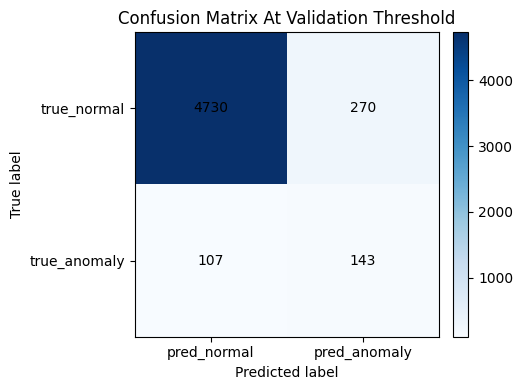

In [14]:
if not evaluation_ready or score_df.empty or pd.isna(threshold):
    warn_skip('Metric review is unavailable because the validation threshold or test scores were not generated.')
else:
    score_df['predicted_anomaly'] = (score_df['score'] > threshold).astype(int)
    precision = precision_score(score_df['is_anomaly'], score_df['predicted_anomaly'], zero_division=0)
    recall = recall_score(score_df['is_anomaly'], score_df['predicted_anomaly'], zero_division=0)
    f1 = f1_score(score_df['is_anomaly'], score_df['predicted_anomaly'], zero_division=0)
    auroc = roc_auc_score(score_df['is_anomaly'], score_df['score'])
    auprc = average_precision_score(score_df['is_anomaly'], score_df['score'])
    cm = confusion_matrix(score_df['is_anomaly'], score_df['predicted_anomaly'])
    metrics_df = pd.DataFrame([{'metric': 'score_name', 'value': ANOMALY_SCORE_NAME}, {'metric': 'precision', 'value': precision}, {'metric': 'recall', 'value': recall}, {'metric': 'f1', 'value': f1}, {'metric': 'auroc', 'value': auroc}, {'metric': 'auprc', 'value': auprc}, {'metric': 'threshold', 'value': threshold}])
    display(metrics_df)
    cm_df = pd.DataFrame(cm, index=['true_normal', 'true_anomaly'], columns=['pred_normal', 'pred_anomaly'])
    display(cm_df)
    fig, ax = plt.subplots(figsize=(5, 4))
    heatmap = ax.imshow(cm_df.to_numpy(), cmap='Blues')
    ax.set_xticks(range(cm_df.shape[1]), cm_df.columns)
    ax.set_yticks(range(cm_df.shape[0]), cm_df.index)
    ax.set_title('Confusion Matrix At Validation Threshold')
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    for row_idx in range(cm_df.shape[0]):
        for col_idx in range(cm_df.shape[1]):
            value = int(cm_df.iat[row_idx, col_idx])
            ax.text(col_idx, row_idx, str(value), ha='center', va='center', color='black')
    fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    save_figure(fig, output_dir / 'plots' / 'confusion_matrix.png')
    plt.show()
    score_df.to_csv(output_dir / 'results' / 'test_scores.csv', index=False)
    metrics_df.to_csv(output_dir / 'results' / 'metrics.csv', index=False)


### Threshold Sweep Plot

This cell compares precision, recall, and F1 across score thresholds, then saves both the table and the figure.


,threshold,precision,recall,f1,predicted_anomalies
5075,0.600826,0.852564,0.532,0.655172,155
5087,0.624338,0.895833,0.516,0.654822,143
5071,0.595891,0.837500,0.536,0.653659,159
5074,0.600500,0.847134,0.532,0.653563,156
5080,0.606339,0.867550,0.524,0.653367,150
5083,0.617530,0.878378,0.520,0.653266,147
5086,0.622787,0.889655,0.516,0.653165,144
5089,0.624870,0.901408,0.512,0.653061,141
5070,0.595750,0.832298,0.536,0.652068,160
5073,0.598530,0.841772,0.532,0.651961,157


Best F1 threshold: 0.600826 | precision=0.8526, recall=0.5320, f1=0.6552
Saved figure to C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\autoencoder\x64\batchnorm\artifacts\autoencoder_batchnorm\plots\threshold_sweep.png


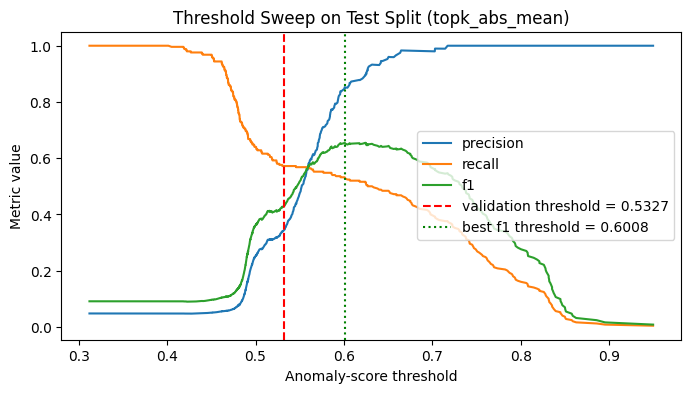

In [15]:
if not evaluation_ready or score_df.empty or pd.isna(threshold):
    warn_skip('Threshold-sweep review is unavailable because evaluation scores were not generated.')
else:
    precision_curve, recall_curve, pr_thresholds = precision_recall_curve(score_df['is_anomaly'], score_df['score'])
    threshold_sweep_df = pd.DataFrame({'threshold': pr_thresholds, 'precision': precision_curve[:-1], 'recall': recall_curve[:-1]})
    threshold_sweep_df['f1'] = 2 * threshold_sweep_df['precision'] * threshold_sweep_df['recall'] / (threshold_sweep_df['precision'] + threshold_sweep_df['recall'] + 1e-12)
    threshold_sweep_df['predicted_anomalies'] = [int((score_df['score'] > t).sum()) for t in threshold_sweep_df['threshold']]
    best_f1_row = threshold_sweep_df.loc[threshold_sweep_df['f1'].idxmax()]
    threshold_sweep_df.to_csv(output_dir / 'results' / 'threshold_sweep.csv', index=False)
    display(threshold_sweep_df.sort_values('f1', ascending=False).head(10))
    print(f"Best F1 threshold: {best_f1_row['threshold']:.6f} | precision={best_f1_row['precision']:.4f}, recall={best_f1_row['recall']:.4f}, f1={best_f1_row['f1']:.4f}")
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(threshold_sweep_df['threshold'], threshold_sweep_df['precision'], label='precision')
    ax.plot(threshold_sweep_df['threshold'], threshold_sweep_df['recall'], label='recall')
    ax.plot(threshold_sweep_df['threshold'], threshold_sweep_df['f1'], label='f1')
    ax.axvline(threshold, color='red', linestyle='--', label=f'validation threshold = {threshold:.4f}')
    ax.axvline(best_f1_row['threshold'], color='green', linestyle=':', label=f"best f1 threshold = {best_f1_row['threshold']:.4f}")
    ax.set_xlabel('Anomaly-score threshold')
    ax.set_ylabel('Metric value')
    ax.set_title(f'Threshold Sweep on Test Split ({ANOMALY_SCORE_NAME})')
    ax.legend()
    save_figure(fig, output_dir / 'plots' / 'threshold_sweep.png')
    plt.show()


### Score Distribution Plot

This cell visualizes the test-score distribution for normal and anomalous wafers and saves the histogram figure.


Saved figure to C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\autoencoder\x64\batchnorm\artifacts\autoencoder_batchnorm\plots\score_distribution.png


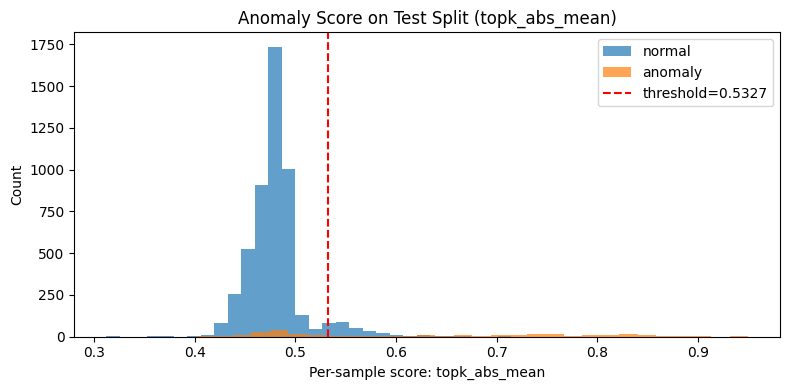

In [16]:
if not evaluation_ready or score_df.empty or pd.isna(threshold):
    warn_skip('Score-distribution plots are unavailable because evaluation scores were not generated.')
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(score_df[score_df['is_anomaly'] == 0]['score'], bins=30, alpha=0.7, label='normal')
    ax.hist(score_df[score_df['is_anomaly'] == 1]['score'], bins=30, alpha=0.7, label='anomaly')
    ax.axvline(threshold, color='red', linestyle='--', label=f'threshold={threshold:.4f}')
    ax.set_title(f'Anomaly Score on Test Split ({ANOMALY_SCORE_NAME})')
    ax.set_xlabel(f'Per-sample score: {ANOMALY_SCORE_NAME}')
    ax.set_ylabel('Count')
    ax.legend()
    plt.tight_layout()
    save_figure(fig, output_dir / 'plots' / 'score_distribution.png')
    plt.show()


### Reconstruction Examples

This cell shows a small set of input and reconstruction pairs and saves the figure.


Saved figure to C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\autoencoder\x64\batchnorm\artifacts\autoencoder_batchnorm\plots\reconstruction_examples.png


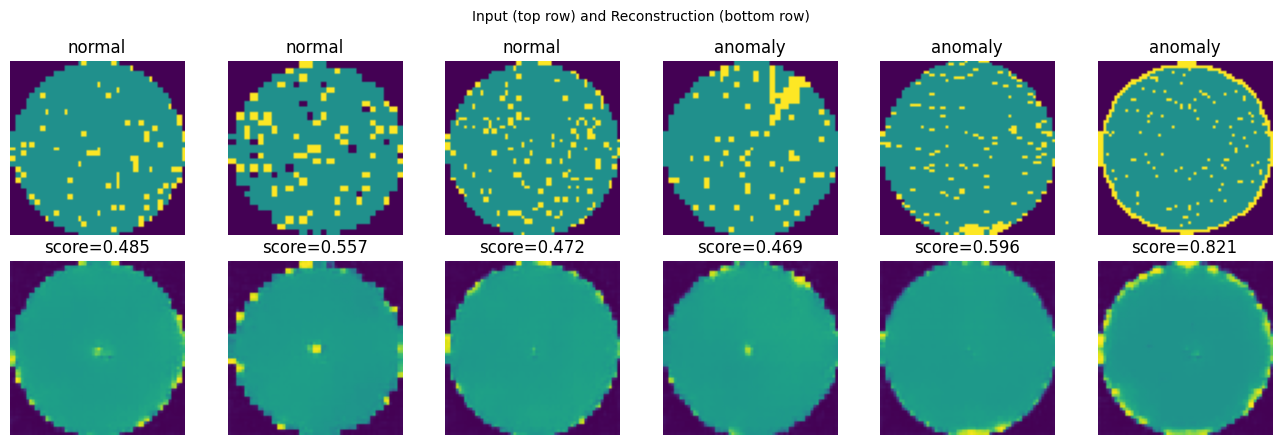

In [17]:
if not evaluation_ready or score_df.empty:
    warn_skip('Reconstruction examples are unavailable because evaluation scores were not generated.')
else:
    normal_test_idx = score_df[score_df['is_anomaly'] == 0].index[:3].tolist()
    anomaly_test_idx = score_df[score_df['is_anomaly'] == 1].index[:3].tolist()
    selected_indices = normal_test_idx + anomaly_test_idx
    fig, axes = plt.subplots(2, len(selected_indices), figsize=(2.2 * len(selected_indices), 4.5))
    with torch.no_grad():
        for col_idx, sample_idx in enumerate(selected_indices):
            input_tensor, label = test_dataset[sample_idx]
            output_tensor = model(input_tensor.unsqueeze(0).to(device)).squeeze(0).cpu()
            title_prefix = 'anomaly' if int(label) == 1 else 'normal'
            score = score_df.iloc[sample_idx]['score']
            axes[0, col_idx].imshow(input_tensor.squeeze(0), cmap='viridis')
            axes[0, col_idx].set_title(f'{title_prefix}')
            axes[0, col_idx].axis('off')
            axes[1, col_idx].imshow(output_tensor.squeeze(0), cmap='viridis')
            axes[1, col_idx].set_title(f'score={score:.3f}')
            axes[1, col_idx].axis('off')
    plt.suptitle('Input (top row) and Reconstruction (bottom row)', fontsize=10, y=0.98)
    plt.tight_layout()
    save_figure(fig, output_dir / 'plots' / 'reconstruction_examples.png')
    plt.show()


### Failure Tables

This cell builds the error-analysis table and saves the detailed failure-analysis CSV for later reference.


In [18]:
if not evaluation_ready or score_df.empty or 'predicted_anomaly' not in score_df.columns:
    warn_skip('Failure analysis is unavailable because evaluation outputs were not generated.')
    analysis_df = pd.DataFrame()
else:
    analysis_df = test_dataset.metadata.reset_index(drop=True).copy()
    analysis_df = pd.concat([analysis_df, score_df[['score', 'predicted_anomaly']].reset_index(drop=True)], axis=1)
    analysis_df['error_type'] = 'tn'
    analysis_df.loc[(analysis_df['is_anomaly'] == 0) & (analysis_df['predicted_anomaly'] == 1), 'error_type'] = 'fp'
    analysis_df.loc[(analysis_df['is_anomaly'] == 1) & (analysis_df['predicted_anomaly'] == 0), 'error_type'] = 'fn'
    analysis_df.loc[(analysis_df['is_anomaly'] == 1) & (analysis_df['predicted_anomaly'] == 1), 'error_type'] = 'tp'
    analysis_df['correct'] = analysis_df['is_anomaly'] == analysis_df['predicted_anomaly']
    error_summary_df = analysis_df.groupby('error_type').agg(count=('error_type', 'size'), mean_score=('score', 'mean')).reindex(['tp', 'fn', 'fp', 'tn'])
    defect_recall_df = analysis_df[analysis_df['is_anomaly'] == 1].groupby('defect_type').agg(count=('defect_type', 'size'), detected=('predicted_anomaly', 'sum'), mean_score=('score', 'mean')).sort_values(['detected', 'count'], ascending=[False, False])
    defect_recall_df['recall'] = defect_recall_df['detected'] / defect_recall_df['count']
    fp_defect_df = analysis_df[analysis_df['error_type'] == 'fp'].groupby('defect_type').agg(count=('defect_type', 'size'), mean_score=('score', 'mean')).sort_values(['count', 'mean_score'], ascending=[False, False])
    display(error_summary_df)
    display(defect_recall_df)
    display(fp_defect_df)
    display(analysis_df.head())
    analysis_df.to_csv(output_dir / 'results' / 'failure_analysis.csv', index=False)
    error_summary_df.to_csv(output_dir / 'results' / 'failure_error_summary.csv')
    defect_recall_df.to_csv(output_dir / 'results' / 'failure_defect_recall.csv')
    fp_defect_df.to_csv(output_dir / 'results' / 'failure_false_positive_breakdown.csv')


,count,mean_score
error_type,,
tp,143,0.740248
fn,107,0.478619
fp,270,0.562314
tn,4730,0.475181


,count,detected,mean_score,recall
defect_type,,,,
Edge-Ring,84,70,0.736288,0.833333
Center,50,35,0.643325,0.700000
Edge-Loc,53,21,0.561323,0.396226
Loc,34,6,0.501656,0.176471
Scratch,15,3,0.515605,0.200000
Donut,7,3,0.551153,0.428571
Random,5,3,0.595819,0.600000
Near-full,2,2,0.837805,1.000000


,count,mean_score
defect_type,,
none,270,0.562314


,array_path,failure_type,failureTypeText,defect_type,label,is_anomaly,split,score,predicted_anomaly,error_type,correct
0,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...,none,none,none,none,0,test,0.485152,0,tn,True
1,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...,none,none,none,none,0,test,0.557461,1,fp,False
2,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...,none,none,none,none,0,test,0.472061,0,tn,True
3,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...,none,none,none,none,0,test,0.486032,0,tn,True
4,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...,none,none,none,none,0,test,0.478871,0,tn,True


### Failure Examples

This cell visualizes representative false positives, false negatives, true positives, and true negatives and saves each figure.


Saved figure to C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\autoencoder\x64\batchnorm\artifacts\autoencoder_batchnorm\plots\failure_examples_fp.png


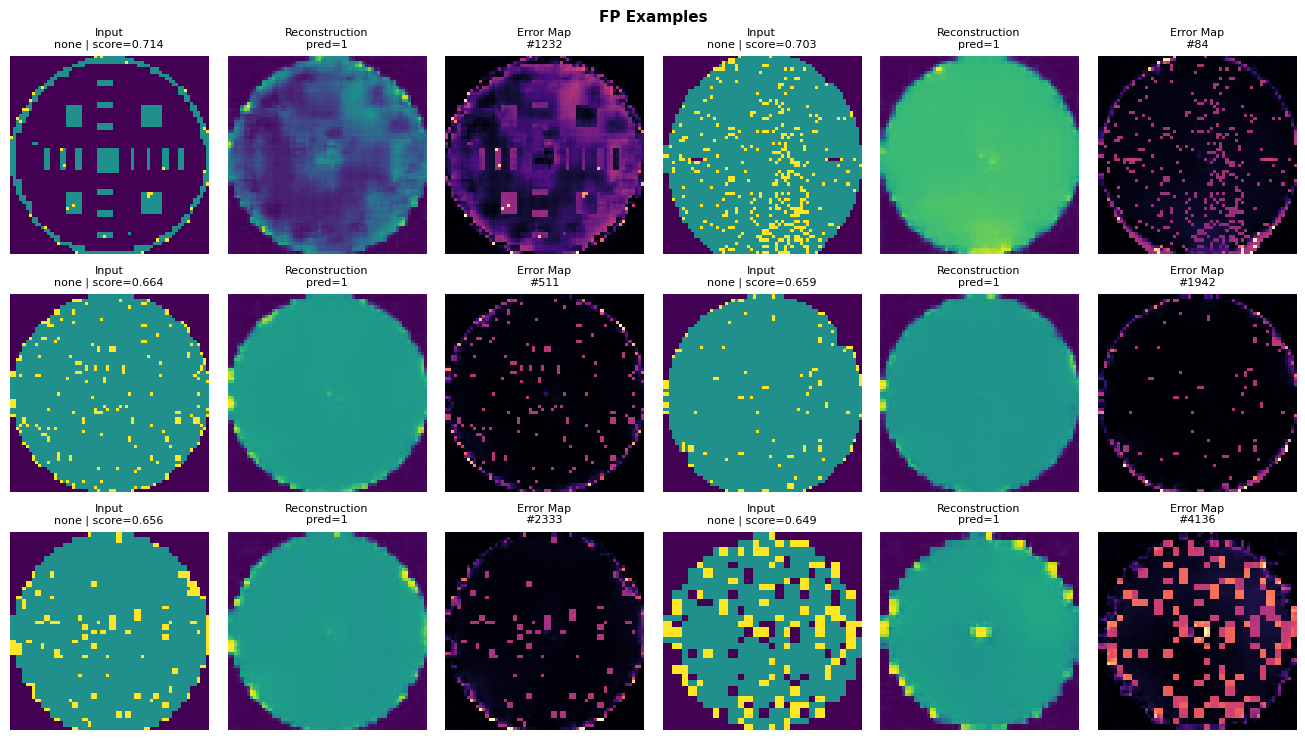

,defect_type,score,predicted_anomaly,error_type
1232,none,0.714457,1,fp
84,none,0.702723,1,fp
511,none,0.663619,1,fp
1942,none,0.659404,1,fp
2333,none,0.656339,1,fp
4136,none,0.649196,1,fp


Saved figure to C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\autoencoder\x64\batchnorm\artifacts\autoencoder_batchnorm\plots\failure_examples_fn.png


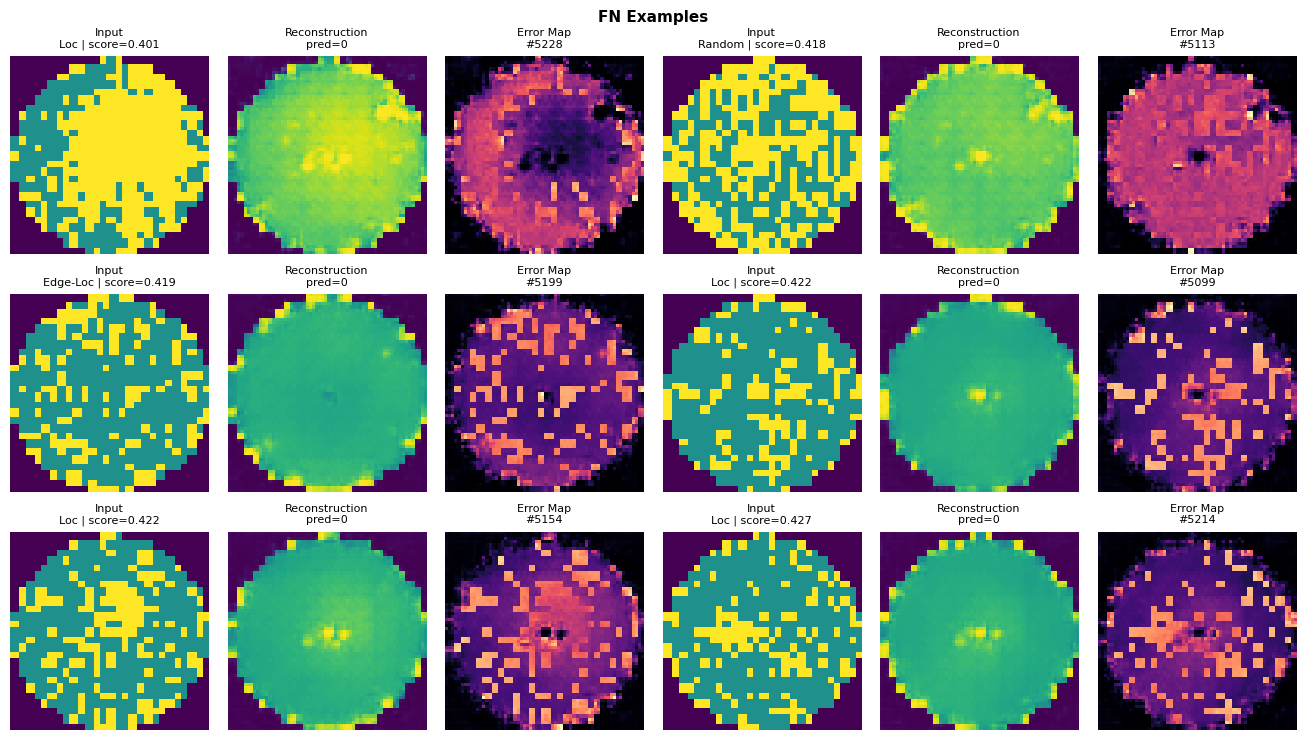

,defect_type,score,predicted_anomaly,error_type
5228,Loc,0.401440,0,fn
5113,Random,0.418481,0,fn
5199,Edge-Loc,0.419259,0,fn
5099,Loc,0.421584,0,fn
5154,Loc,0.422121,0,fn
5214,Loc,0.426755,0,fn


Saved figure to C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\autoencoder\x64\batchnorm\artifacts\autoencoder_batchnorm\plots\failure_examples_tp.png


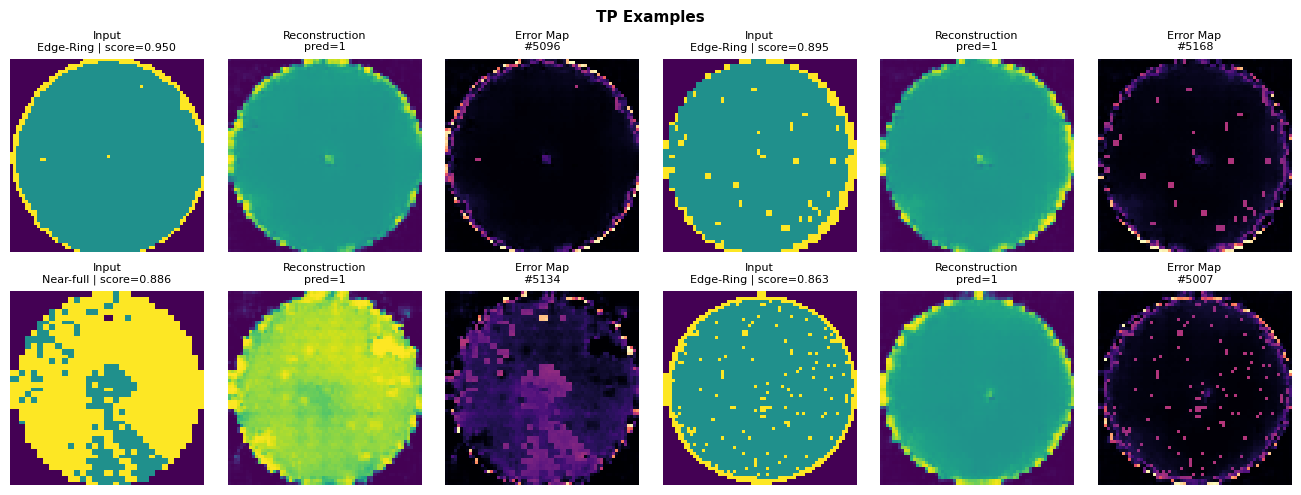

,defect_type,score,predicted_anomaly,error_type
5096,Edge-Ring,0.949625,1,tp
5168,Edge-Ring,0.895238,1,tp
5134,Near-full,0.885803,1,tp
5007,Edge-Ring,0.862606,1,tp


Saved figure to C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\autoencoder\x64\batchnorm\artifacts\autoencoder_batchnorm\plots\failure_examples_tn.png


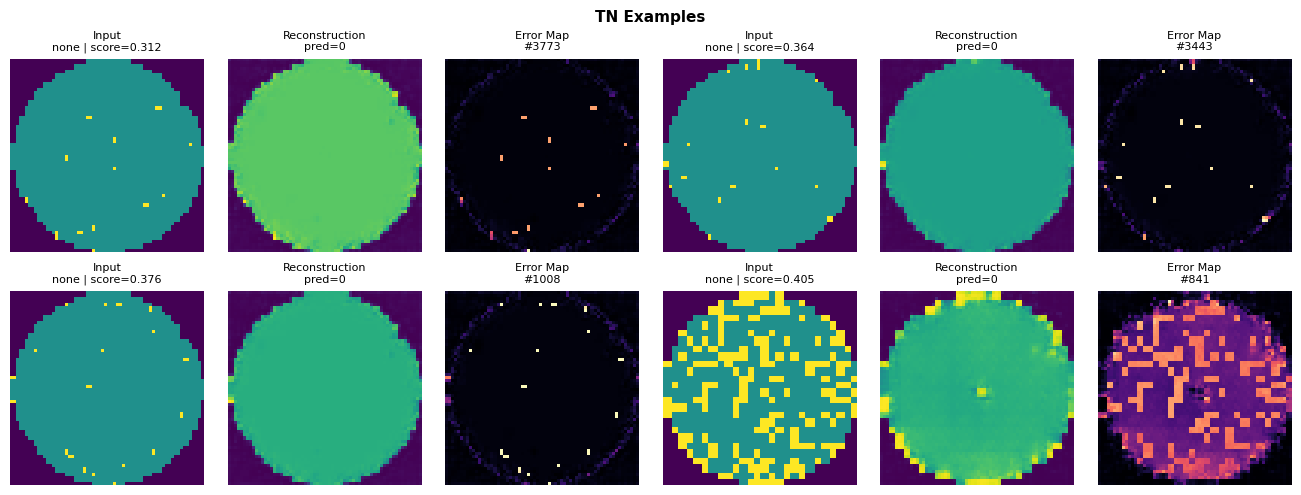

,defect_type,score,predicted_anomaly,error_type
3773,none,0.312166,0,tn
3443,none,0.363934,0,tn
1008,none,0.375783,0,tn
841,none,0.405015,0,tn


In [19]:
def show_error_examples(error_type: str, n_examples: int=6, score_order: str='desc') -> pd.DataFrame:
    if 'analysis_df' not in globals() or analysis_df.empty:
        print(f'Failure analysis is unavailable for error_type={error_type!r}.')
        return pd.DataFrame()
    subset = analysis_df[analysis_df['error_type'] == error_type].copy()
    if subset.empty:
        print(f'No samples found for error_type={error_type!r}.')
        return subset
    ascending = score_order == 'asc'
    subset = subset.sort_values('score', ascending=ascending).head(n_examples)
    n_rows = (len(subset) + 1) // 2
    fig, axes = plt.subplots(n_rows, 6, figsize=(6 * 2.2, n_rows * 2.5))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    with torch.no_grad():
        for plot_idx, (sample_idx, row) in enumerate(subset.iterrows()):
            row_idx = plot_idx // 2
            col_start = plot_idx % 2 * 3
            input_tensor, label = test_dataset[sample_idx]
            output_tensor = model(input_tensor.unsqueeze(0).to(device)).squeeze(0).cpu()
            error_map = absolute_error_map(input_tensor.unsqueeze(0), output_tensor.unsqueeze(0)).squeeze(0).squeeze(0).cpu()
            axes[row_idx, col_start].imshow(input_tensor.squeeze(0), cmap='viridis')
            axes[row_idx, col_start].set_title(f"Input\n{row.get('defect_type', '?')} | score={row['score']:.3f}", fontsize=8)
            axes[row_idx, col_start].axis('off')
            axes[row_idx, col_start + 1].imshow(output_tensor.squeeze(0), cmap='viridis')
            axes[row_idx, col_start + 1].set_title(f"Reconstruction\npred={row['predicted_anomaly']}", fontsize=8)
            axes[row_idx, col_start + 1].axis('off')
            axes[row_idx, col_start + 2].imshow(error_map, cmap='magma')
            axes[row_idx, col_start + 2].set_title(f'Error Map\n#{sample_idx}', fontsize=8)
            axes[row_idx, col_start + 2].axis('off')
    for idx in range(len(subset) * 3, n_rows * 6):
        row_idx = idx // 6
        col_idx = idx % 6
        axes[row_idx, col_idx].axis('off')
    plt.suptitle(f'{error_type.upper()} Examples', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.2)
    save_figure(fig, output_dir / 'plots' / f'failure_examples_{error_type}.png')
    plt.show()
    return subset[['defect_type', 'score', 'predicted_anomaly', 'error_type']]

if 'analysis_df' not in globals() or analysis_df.empty:
    warn_skip('Failure-example review is unavailable because failure analysis was not generated.')
else:
    display(show_error_examples('fp', n_examples=6, score_order='desc'))
    display(show_error_examples('fn', n_examples=6, score_order='asc'))
    display(show_error_examples('tp', n_examples=4, score_order='desc'))
    display(show_error_examples('tn', n_examples=4, score_order='asc'))


### Score Ablation Run

This cell runs the score-ablation helper only when its outputs are missing or rerun is explicitly requested.


In [20]:
import os
import subprocess

score_ablation_config = config if 'config' in globals() else load_toml(CONFIG_PATH)
score_ablation_output_root = REPO_ROOT / score_ablation_config['run']['output_dir']
score_ablation_best_model_path = score_ablation_output_root / 'checkpoints' / 'best_model.pt'
score_ablation_output_dir = score_ablation_output_root / 'results' / 'score_ablation'
score_ablation_output_dir.mkdir(parents=True, exist_ok=True)
score_ablation_csv_path = score_ablation_output_dir / 'score_summary.csv'
score_ablation_json_path = score_ablation_output_dir / 'score_summary.json'
score_ablation_cmd = [sys.executable, 'scripts/evaluate_autoencoder_scores.py', '--checkpoint', str(score_ablation_best_model_path.relative_to(REPO_ROOT)), '--config', str(CONFIG_PATH.relative_to(REPO_ROOT)), '--output-dir', str(score_ablation_output_dir.relative_to(REPO_ROOT))]
score_ablation_env = os.environ.copy()
src_path = str(REPO_ROOT / 'src')
score_ablation_env['PYTHONPATH'] = src_path if not score_ablation_env.get('PYTHONPATH') else src_path + os.pathsep + score_ablation_env['PYTHONPATH']
score_ablation_ready = False
if RERUN_SCORE_ABLATION:
    if not score_ablation_best_model_path.exists():
        warn_skip(f'Best autoencoder checkpoint not found: {score_ablation_best_model_path}. Skipping score ablation review.')
    elif 'val_loader' not in globals() or val_loader is None or test_loader is None:
        warn_skip('Score ablation needs the validation/test datasets, which are unavailable for this cell.')
    else:
        print('Running:')
        print(' '.join(score_ablation_cmd))
        subprocess.run(score_ablation_cmd, cwd=REPO_ROOT, env=score_ablation_env, check=True)
        score_ablation_ready = True
elif score_ablation_csv_path.exists() and score_ablation_json_path.exists():
    print(f'Found existing score ablation outputs in {score_ablation_output_dir}. Skipping rerun.')
    score_ablation_ready = True
else:
    warn_skip('Score ablation artifacts are missing and RERUN_SCORE_ABLATION is False. Skipping this section.')


Found existing score ablation outputs in C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\autoencoder\x64\batchnorm\artifacts\autoencoder_batchnorm\results\score_ablation. Skipping rerun.


### Score Ablation Results

This cell loads the saved score-ablation outputs so they can be inspected without rerunning the script.


In [21]:
if not score_ablation_ready:
    warn_skip('Score ablation tables are unavailable because the score-ablation artifacts are missing.')
    score_ablation_df = pd.DataFrame()
    score_ablation_summary = {}
else:
    score_ablation_df = pd.read_csv(score_ablation_output_dir / 'score_summary.csv')
    score_ablation_summary = json.loads((score_ablation_output_dir / 'score_summary.json').read_text(encoding='utf-8'))
    display(score_ablation_df)
    display(score_ablation_summary)


,score_name,threshold,val_threshold_precision,val_threshold_recall,val_threshold_f1,auroc,auprc,best_sweep_threshold,best_sweep_precision,best_sweep_recall,best_sweep_f1
0,max_abs,0.759817,0.401442,0.668,0.501502,0.834023,0.568039,0.953788,0.789157,0.524,0.629808
1,topk_abs_mean,0.532667,0.346247,0.572,0.431373,0.790020,0.603447,0.600826,0.852564,0.532,0.655172
2,mse_mean,0.025888,0.278090,0.396,0.326733,0.779451,0.345216,0.029245,0.513333,0.308,0.385000
3,foreground_mse,0.032778,0.233696,0.344,0.278317,0.738702,0.278022,0.037370,0.448276,0.260,0.329114
4,mae_mean,0.107230,0.222222,0.312,0.259567,0.728685,0.284041,0.118471,0.404624,0.280,0.330969
5,pooled_mae_mean,0.105898,0.220630,0.308,0.257095,0.722959,0.278594,0.120462,0.466165,0.248,0.323760
6,foreground_mae,0.135362,0.208696,0.288,0.242017,0.700971,0.244630,0.159888,0.542553,0.204,0.296512


{'checkpoint': 'artifacts\\x64\\autoencoder_batchnorm\\best_model.pt',
 'topk_ratio': 0.01,
 'foreground_threshold': 0.0,
 'pool_kernel_size': 5,
 'threshold_quantile': 0.95,
 'scores': [{'score_name': 'max_abs',
   'threshold': 0.7598166525363923,
   'val_threshold_precision': 0.4014423076923077,
   'val_threshold_recall': 0.668,
   'val_threshold_f1': 0.5015015015015015,
   'auroc': 0.8340228000000001,
   'auprc': 0.5680390009443157,
   'best_sweep_threshold': 0.9537878632545471,
   'best_sweep_precision': 0.7891566265060241,
   'best_sweep_recall': 0.524,
   'best_sweep_f1': 0.6298076923072127},
  {'score_name': 'topk_abs_mean',
   'threshold': 0.5326668411493302,
   'val_threshold_precision': 0.34624697336561744,
   'val_threshold_recall': 0.572,
   'val_threshold_f1': 0.43137254901960786,
   'auroc': 0.79002,
   'auprc': 0.6034473058936911,
   'best_sweep_threshold': 0.6008264422416687,
   'best_sweep_precision': 0.8525641025641025,
   'best_sweep_recall': 0.532,
   'best_sweep_f1

### Score Ablation Plot

This cell visualizes the score-ablation comparison and saves the summary plot.


Saved figure to C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\autoencoder\x64\batchnorm\artifacts\autoencoder_batchnorm\plots\score_ablation_summary.png


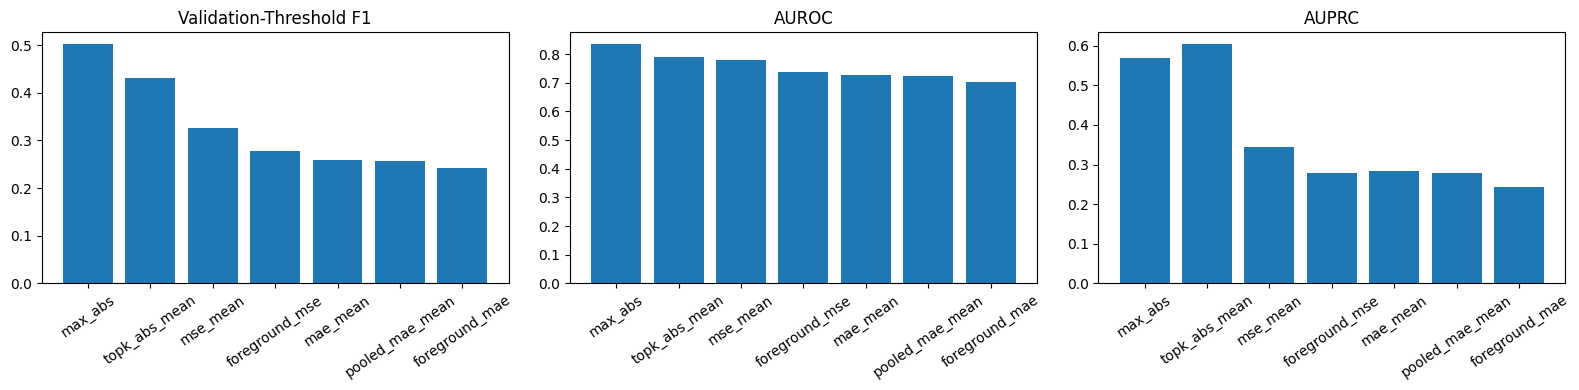

,score_name,val_threshold_f1,auroc,auprc,best_sweep_f1
0,max_abs,0.501502,0.834023,0.568039,0.629808
1,topk_abs_mean,0.431373,0.790020,0.603447,0.655172
2,mse_mean,0.326733,0.779451,0.345216,0.385000
3,foreground_mse,0.278317,0.738702,0.278022,0.329114
4,mae_mean,0.259567,0.728685,0.284041,0.330969
5,pooled_mae_mean,0.257095,0.722959,0.278594,0.323760
6,foreground_mae,0.242017,0.700971,0.244630,0.296512


In [22]:
if not score_ablation_ready or score_ablation_df.empty:
    warn_skip('Score ablation plots are unavailable because the score-ablation artifacts are missing.')
else:
    top_scores = score_ablation_df.sort_values('val_threshold_f1', ascending=False).reset_index(drop=True)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].bar(top_scores['score_name'], top_scores['val_threshold_f1'])
    axes[0].set_title('Validation-Threshold F1')
    axes[0].tick_params(axis='x', rotation=35)
    axes[1].bar(top_scores['score_name'], top_scores['auroc'])
    axes[1].set_title('AUROC')
    axes[1].tick_params(axis='x', rotation=35)
    axes[2].bar(top_scores['score_name'], top_scores['auprc'])
    axes[2].set_title('AUPRC')
    axes[2].tick_params(axis='x', rotation=35)
    plt.tight_layout()
    save_figure(fig, score_ablation_output_root / 'plots' / 'score_ablation_summary.png')
    plt.show()
    display(top_scores[['score_name', 'val_threshold_f1', 'auroc', 'auprc', 'best_sweep_f1']])


---

## Holdout Evaluation: Expanded 70k Normal / 3.5k Defect Test Set

This section evaluates the saved checkpoint on the secondary holdout split.

The holdout keeps the same 40k training normals and 5k validation normals as the main
benchmark, but replaces the test set with a much larger pool:
**70,000 normal + 3,500 defect** wafers.

This is a robustness check - the checkpoint and threshold policy do not change.

Note: `reconstruction_error` inside this notebook only supports `topk_abs_mean` and `mse_mean`.
To evaluate `max_abs` on the holdout, use `scripts/evaluate_autoencoder_scores.py` directly.


In [23]:
HOLDOUT_METADATA_PATH = REPO_ROOT / 'data/processed/x64/wm811k/metadata_50k_5pct_holdout70k_3p5k.csv'
HOLDOUT_SCORE_NAME = 'topk_abs_mean'
HOLDOUT_THRESHOLD_QUANTILE = 0.95
HOLDOUT_OUTPUT_DIR = output_dir / 'holdout70k_3p5k'
print(f'Holdout metadata: {HOLDOUT_METADATA_PATH}')
print(f'Exists:           {HOLDOUT_METADATA_PATH.exists()}')
print(f'Score:            {HOLDOUT_SCORE_NAME}')
print(f'Output dir:       {HOLDOUT_OUTPUT_DIR}')


Holdout metadata: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\data\processed\x64\wm811k\metadata_50k_5pct_holdout70k_3p5k.csv
Exists:           True
Score:            topk_abs_mean
Output dir:       C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\autoencoder\x64\batchnorm\artifacts\autoencoder_batchnorm\holdout70k_3p5k


Loading holdout datasets...
  Val:  5,000 wafers
  Test: 73,500 wafers

Holdout threshold (95% of val normals): 0.532667

-- Holdout Evaluation Results -------------------------------
  Score:               topk_abs_mean
  Threshold:           0.532667
  Precision:           0.373784
  Recall:              0.625714
  F1:                  0.467999
  AUROC:               0.803133
  AUPRC:               0.637889
  Test normals:        70,000
  Test anomalies:      3,500
  Predicted anomalies: 5,859

-- Per-Defect Recall ----------------------------------------


,defect_type,count,detected,recall
4,Loc,492.0,113.0,0.229675
7,Scratch,169.0,44.0,0.260355
1,Donut,71.0,26.0,0.366197
2,Edge-Loc,739.0,311.0,0.420839
6,Random,108.0,73.0,0.675926
0,Center,603.0,417.0,0.691542
5,Near-full,16.0,14.0,0.875000
3,Edge-Ring,1302.0,1192.0,0.915515



Best sweep F1: 0.692990 at threshold 0.614905
Saved figure to C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\autoencoder\x64\batchnorm\artifacts\autoencoder_batchnorm\holdout70k_3p5k\holdout_distribution_sweep.png


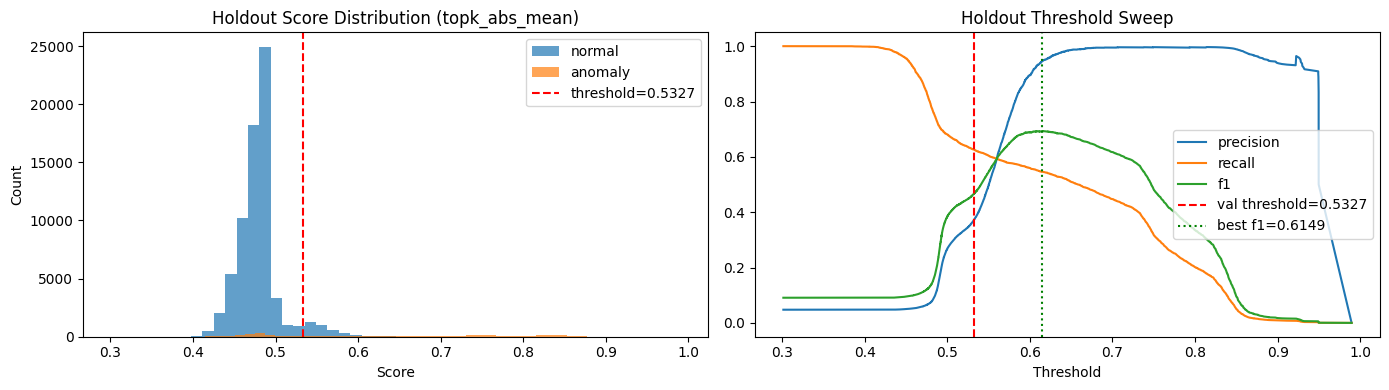


Results saved to C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\autoencoder\x64\batchnorm\artifacts\autoencoder_batchnorm\holdout70k_3p5k


In [24]:
if not RUN_HOLDOUT_EVALUATION:
    print('Holdout evaluation skipped.')
else:
    HOLDOUT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    print('Loading holdout datasets...')
    holdout_val_ds = WaferMapDataset(HOLDOUT_METADATA_PATH, split='val', image_size=image_size)
    holdout_test_ds = WaferMapDataset(HOLDOUT_METADATA_PATH, split='test', image_size=image_size)
    holdout_val_loader = DataLoader(holdout_val_ds, batch_size=64, shuffle=False, num_workers=0)
    holdout_test_loader = DataLoader(holdout_test_ds, batch_size=64, shuffle=False, num_workers=0)
    print(f'  Val:  {len(holdout_val_ds):,} wafers')
    print(f'  Test: {len(holdout_test_ds):,} wafers')
    model.eval()
    holdout_val_scores, holdout_val_labels = ([], [])
    with torch.no_grad():
        for imgs, labels in holdout_val_loader:
            imgs = imgs.to(device)
            recon = model(imgs)
            scores = reconstruction_error(imgs, recon, score_name=HOLDOUT_SCORE_NAME).cpu().numpy()
            holdout_val_scores.extend(scores.tolist())
            holdout_val_labels.extend(labels.tolist())
    holdout_val_scores = np.array(holdout_val_scores)
    holdout_val_labels = np.array(holdout_val_labels)
    holdout_threshold = float(np.quantile(holdout_val_scores[holdout_val_labels == 0], HOLDOUT_THRESHOLD_QUANTILE))
    print(f'\nHoldout threshold ({HOLDOUT_THRESHOLD_QUANTILE:.0%} of val normals): {holdout_threshold:.6f}')
    holdout_test_scores, holdout_test_labels = ([], [])
    with torch.no_grad():
        for imgs, labels in holdout_test_loader:
            imgs = imgs.to(device)
            recon = model(imgs)
            scores = reconstruction_error(imgs, recon, score_name=HOLDOUT_SCORE_NAME).cpu().numpy()
            holdout_test_scores.extend(scores.tolist())
            holdout_test_labels.extend(labels.tolist())
    holdout_test_scores = np.array(holdout_test_scores)
    holdout_test_labels = np.array(holdout_test_labels)
    holdout_test_preds = (holdout_test_scores >= holdout_threshold).astype(int)
    h_precision = precision_score(holdout_test_labels, holdout_test_preds, zero_division=0)
    h_recall = recall_score(holdout_test_labels, holdout_test_preds, zero_division=0)
    h_f1 = f1_score(holdout_test_labels, holdout_test_preds, zero_division=0)
    h_auroc = roc_auc_score(holdout_test_labels, holdout_test_scores)
    h_auprc = average_precision_score(holdout_test_labels, holdout_test_scores)
    print(f'\n-- Holdout Evaluation Results -------------------------------')
    print(f'  Score:               {HOLDOUT_SCORE_NAME}')
    print(f'  Threshold:           {holdout_threshold:.6f}')
    print(f'  Precision:           {h_precision:.6f}')
    print(f'  Recall:              {h_recall:.6f}')
    print(f'  F1:                  {h_f1:.6f}')
    print(f'  AUROC:               {h_auroc:.6f}')
    print(f'  AUPRC:               {h_auprc:.6f}')
    print(f'  Test normals:        {int((holdout_test_labels == 0).sum()):,}')
    print(f'  Test anomalies:      {int((holdout_test_labels == 1).sum()):,}')
    print(f'  Predicted anomalies: {int(holdout_test_preds.sum()):,}')
    holdout_meta = holdout_test_ds.metadata.reset_index(drop=True).copy()
    holdout_meta['score'] = holdout_test_scores
    holdout_meta['predicted'] = holdout_test_preds
    defect_col = next((c for c in ['defect_type', 'failureType'] if c in holdout_meta.columns), None)
    if defect_col:
        holdout_defect_df = holdout_meta[holdout_meta['is_anomaly'] == 1].groupby(defect_col).apply(lambda g: pd.Series({'count': len(g), 'detected': int(g['predicted'].sum()), 'recall': g['predicted'].mean()})).reset_index().sort_values('recall')
        print(f'\n-- Per-Defect Recall ----------------------------------------')
        display(holdout_defect_df)
    else:
        holdout_defect_df = pd.DataFrame()
        print('\nNo defect type column found in metadata; per-defect recall skipped.')
    h_prec_curve, h_rec_curve, h_thresholds = precision_recall_curve(holdout_test_labels, holdout_test_scores)
    holdout_sweep_df = pd.DataFrame({'threshold': h_thresholds, 'precision': h_prec_curve[:-1], 'recall': h_rec_curve[:-1]})
    holdout_sweep_df['f1'] = 2 * holdout_sweep_df['precision'] * holdout_sweep_df['recall'] / (holdout_sweep_df['precision'] + holdout_sweep_df['recall'] + 1e-12)
    best_h_row = holdout_sweep_df.loc[holdout_sweep_df['f1'].idxmax()]
    print(f"\nBest sweep F1: {best_h_row['f1']:.6f} at threshold {best_h_row['threshold']:.6f}")
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(holdout_test_scores[holdout_test_labels == 0], bins=50, alpha=0.7, label='normal')
    axes[0].hist(holdout_test_scores[holdout_test_labels == 1], bins=50, alpha=0.7, label='anomaly')
    axes[0].axvline(holdout_threshold, color='red', linestyle='--', label=f'threshold={holdout_threshold:.4f}')
    axes[0].set_title(f'Holdout Score Distribution ({HOLDOUT_SCORE_NAME})')
    axes[0].set_xlabel('Score')
    axes[0].set_ylabel('Count')
    axes[0].legend()
    axes[1].plot(holdout_sweep_df['threshold'], holdout_sweep_df['precision'], label='precision')
    axes[1].plot(holdout_sweep_df['threshold'], holdout_sweep_df['recall'], label='recall')
    axes[1].plot(holdout_sweep_df['threshold'], holdout_sweep_df['f1'], label='f1')
    axes[1].axvline(holdout_threshold, color='red', linestyle='--', label=f'val threshold={holdout_threshold:.4f}')
    axes[1].axvline(best_h_row['threshold'], color='green', linestyle=':', label=f"best f1={best_h_row['threshold']:.4f}")
    axes[1].set_title('Holdout Threshold Sweep')
    axes[1].set_xlabel('Threshold')
    axes[1].legend()
    plt.tight_layout()
    save_figure(fig, HOLDOUT_OUTPUT_DIR / 'holdout_distribution_sweep.png')
    plt.show()
    pd.DataFrame({'score': holdout_val_scores, 'is_anomaly': holdout_val_labels}).to_csv(HOLDOUT_OUTPUT_DIR / 'val_scores.csv', index=False)
    holdout_meta[['score', 'is_anomaly', 'predicted']].to_csv(HOLDOUT_OUTPUT_DIR / 'test_scores.csv', index=False)
    holdout_sweep_df.to_csv(HOLDOUT_OUTPUT_DIR / 'threshold_sweep.csv', index=False)
    if not holdout_defect_df.empty:
        holdout_defect_df.to_csv(HOLDOUT_OUTPUT_DIR / 'defect_recall.csv', index=False)
    pd.DataFrame([{'score_name': HOLDOUT_SCORE_NAME, 'threshold': holdout_threshold, 'threshold_quantile': HOLDOUT_THRESHOLD_QUANTILE, 'precision': h_precision, 'recall': h_recall, 'f1': h_f1, 'auroc': h_auroc, 'auprc': h_auprc, 'best_sweep_f1': float(best_h_row['f1']), 'best_sweep_threshold': float(best_h_row['threshold']), 'test_normal_count': int((holdout_test_labels == 0).sum()), 'test_anomaly_count': int((holdout_test_labels == 1).sum()), 'predicted_anomalies': int(holdout_test_preds.sum())}]).to_csv(HOLDOUT_OUTPUT_DIR / 'summary.csv', index=False)
    print(f'\nResults saved to {HOLDOUT_OUTPUT_DIR}')
